In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from source import tools as tls

In [3]:
path = "output/grid_day/200K_asplund_m3_day/200K_asplund_m3_day_tp.dat"
press, temp, cpress0, ctemp0, cpress1, ctemp1, cpress2, ctemp2, cpress3, ctemp3 = tls.read_helios_tp(path)

In [4]:
#get condensates from dedicated FastChem output
condensates = pd.read_csv("output/grid_day/200K_asplund_m3_day/chemistry/condensates.dat", sep="\\s+")
condensates.rename(columns={'#p(bar)': 'p(bar)'}, inplace=True)

In [5]:
gas_phase = pd.read_csv("output/grid_day/200K_asplund_m3_day/chemistry/chem.dat", sep="\\s+")

In [6]:
# Rename columns without '(' character to have '_frac' suffix
condensates.rename(columns=lambda x: x + '_frac' if '(' not in x else x, inplace=True)

In [7]:
# Get columns that have '(s)', '(l)', or '(s,l)' in the name
cond_columns = [col for col in condensates.columns if '(s)' in col or '(l)' in col or '(s,l)' in col]

In [8]:
gas_columns = [col for col in gas_phase.columns if '(' not in col]

In [9]:
#total condensate abundance
condensates['total_cond'] = condensates[cond_columns].sum(axis=1)

In [10]:
cond_frac_min_max = 1e-5
# find zero->nonzero transitions for condensate columns (do not count the first row as a transition)
transitions = []
for col in cond_columns:
    mask = condensates[col] > 0
    # treat the "previous" value for the first row as True so a True at index 0 is NOT counted as a rise
    rises = (~mask.shift(1, fill_value=True)) & mask
    if rises.any():
        for idx in condensates.index[rises]:
            if (condensates[col] / condensates['total_cond']).max() < cond_frac_min_max:
                continue
            transitions.append({
                'col': col,
                'row': int(idx),
                'p(bar)': condensates.at[idx, 'p(bar)'],
                'T(K)': condensates.at[idx, 'T(K)'],
                'frac_of_cond': condensates.at[idx, col] / condensates.at[idx, 'total_cond'],  # convert to fraction of total condsnates
                'cond_frac': condensates.at[idx, 'total_cond'] / gas_phase.at[idx, 'n_<tot>(cm-3)']
            })

if transitions:
    res = pd.DataFrame(transitions).sort_values(['col','row']).reset_index(drop=True)
    print(f"Found {len(res)} zero->nonzero transitions (excluding first datapoint):")
    print(res)
else:
    print("No zero->nonzero transitions found in cond_columns.")

Found 6 zero->nonzero transitions (excluding first datapoint):
        col  row    p(bar)     T(K)  frac_of_cond     cond_frac
0      C(s)   36  0.000416  224.037      1.000000  1.184270e-06
1      C(s)   38  0.000268  228.155      1.000000  3.148816e-06
2      C(s)   41  0.000139  235.902      1.000000  5.154343e-06
3      C(s)   43  0.000090  241.974      1.000000  7.267001e-06
4      C(s)   45  0.000058  247.150      1.000000  5.647765e-06
5  KCl(s,l)    2  0.719686  218.930      0.002244  1.303054e-11


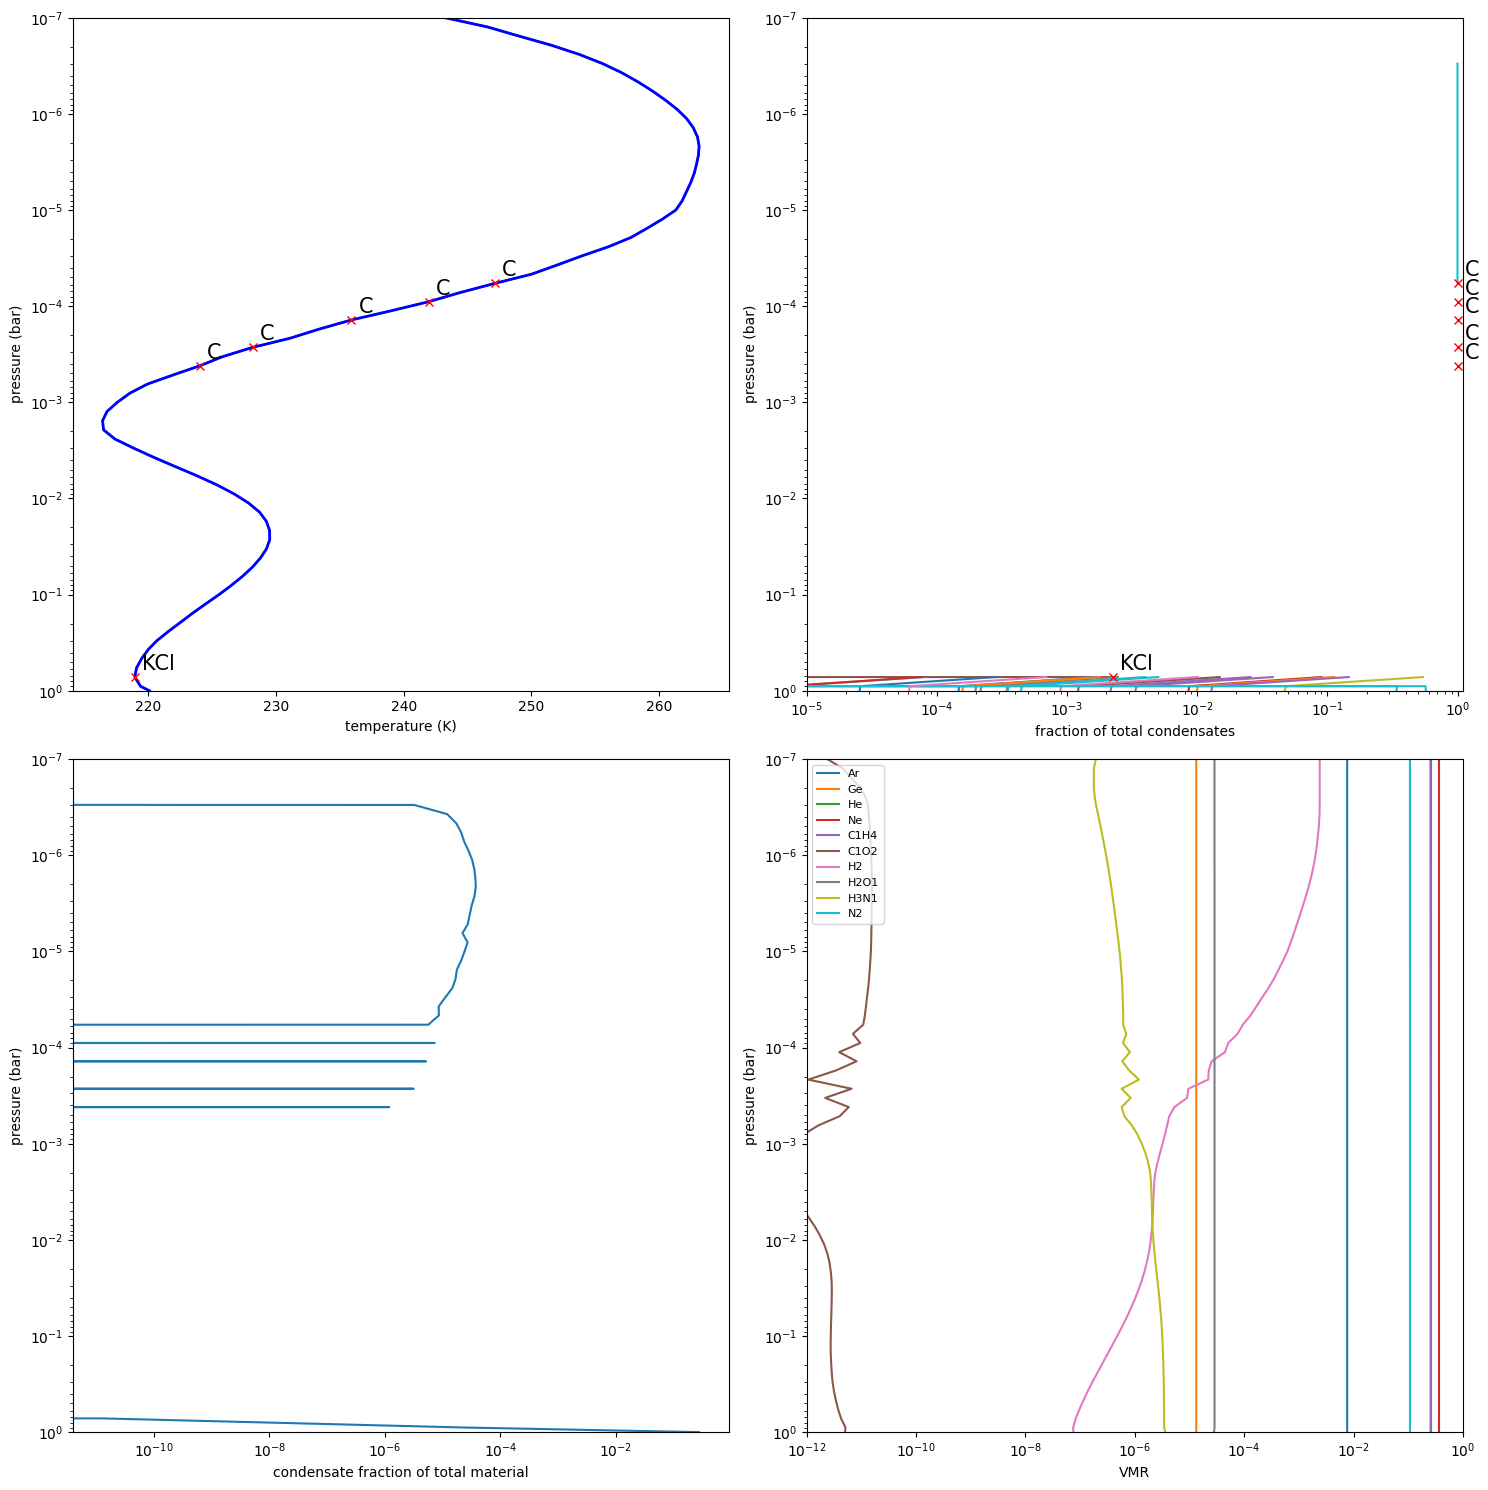

In [13]:
color='blue'
shade='lightblue'
width=2
style='-'
gas_min_max = 1e-12

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 15))
#plot temperature - pressure profile in panel 1
ax1.plot(condensates['T(K)'], condensates['p(bar)'])
ax1.plot(ctemp0, cpress0, color=shade,linewidth=8, alpha=0.7)
ax1.plot(ctemp1, cpress1, color=shade,linewidth=8, alpha=0.7)
ax1.plot(ctemp2, cpress2, color=shade,linewidth=8, alpha=0.7)
ax1.plot(ctemp3, cpress3, color=shade,linewidth=8, alpha=0.7)

line, = ax1.plot(temp, press, color=color, linewidth=width, linestyle=style, alpha=1)
ax1.set(ylim=[1e0, 1e-7], yscale='log', xlabel=r'temperature (K)',ylabel=r'pressure (bar)')
for transition in transitions:
    ax1.plot(transition['T(K)'], transition['p(bar)'], color='red', marker='x')
    ax1.annotate(transition['col'].split('(')[0], xy=(transition['T(K)'], transition['p(bar)']), xytext=(5, 5), textcoords='offset points', fontsize=15)

for col in cond_columns:
    ax2.plot(condensates[col]/condensates['total_cond'], condensates['p(bar)'], label=col)
ax2.set(xscale='log', yscale='log', ylim=[1e-0, 1e-7], xlim=[cond_frac_min_max, 1.1], ylabel=r'pressure (bar)', xlabel=r'fraction of total condensates')
for transition in transitions:
    ax2.plot(transition['frac_of_cond'], transition['p(bar)'], color='red', marker='x')
    ax2.annotate(transition['col'].split('(')[0], xy=(transition['frac_of_cond'], transition['p(bar)']), xytext=(5, 5), textcoords='offset points', fontsize=15)


ax3.plot(condensates['total_cond'] / gas_phase['n_<tot>(cm-3)'], condensates['p(bar)'])
ax3.set(xscale='log', yscale='log', ylim=[1e-0, 1e-7], ylabel=r'pressure (bar)', xlabel=r'condensate fraction of total material')
plt.tight_layout()

for col in gas_columns:
    if gas_phase[col].max() > gas_min_max:
        ax4.plot(gas_phase[col], gas_phase['#p(bar)'], label=col)
ax4.set(xscale='log', yscale='log', ylim=[1e-0, 1e-7], xlim=[gas_min_max, 1], ylabel=r'pressure (bar)', xlabel=r'VMR')
ax4.legend(loc='upper left', fontsize=8)


IndexError: index 0 is out of bounds for axis 0 with size 0

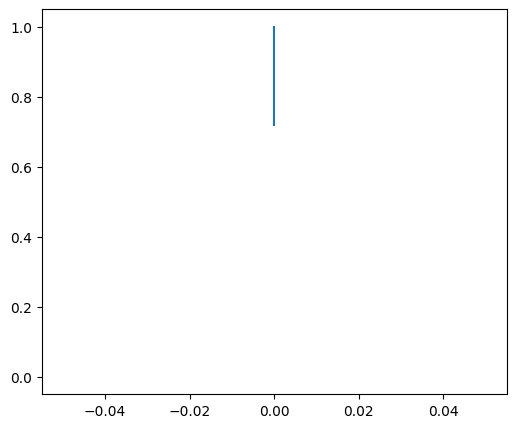

In [15]:
#zoom in on the bottom of the atmosphere
fig, ax = plt.subplots(figsize=(6, 5))
for col in cond_columns:
    ax.plot(condensates[col]/condensates['total_cond'], condensates['p(bar)'], label=col)
    temperature_appears = condensates['T(K)'][condensates[col]/condensates['total_cond'] > 1e-5].max()
    idx_appears = condensates[condensates['T(K)'] == temperature_appears].index[0]
    value_appears = condensates[col][idx_appears]/condensates['total_cond'][idx_appears]
    # ax.annotate(col, xy=(condensates[col]/condensates['total_cond'], condensates['p(bar)']), xytext=(5, 5), textcoords='offset points', fontsize=13)
ax.set(xscale='log', yscale='log', xlim=[1e-7, 1e-0], ylim=[1e-0, 3e-1], ylabel=r'pressure (bar)', xlabel=r'fraction of total condensates')